<a href="https://colab.research.google.com/github/Oliwia501/customer-lifetime-value-prediction/blob/main/customer_lifetime_value_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI for Communication and Marketing
# Customer Lifetime Value (CLTV) Prediction

**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  

---

## Project Overview

This project develops a Customer Lifetime Value (CLTV) prediction framework for Olist, a large Brazilian e-commerce marketplace.

The objective is to estimate the future value of customers using both probabilistic and machine learning approaches, enabling data-driven marketing and budget allocation decisions.

The analysis follows four main stages:

1. Data audit and preprocessing
2. Exploratory data analysis (EDA)
3. CLTV modeling and evaluation
4. Marketing recommendations

Two modeling approaches are compared:

- **BTYD (Buy Till You Die)** models for probabilistic CLTV estimation
- **Machine Learning** models for holdout-period revenue prediction

The final goal is to identify high-value customers and support targeted marketing strategies.

## Environment Setup

In [2]:
!pip install lifetimes --quiet
!pip install xgboost --quiet
!pip install -q kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 8.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import kagglehub
warnings.filterwarnings('ignore')
from pathlib import Path

# Sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# XGBoost
from xgboost import XGBRegressor

# Lifetimes (BTYD models)
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions
)

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Data Loading

The Olist dataset consists of multiple relational tables. The following datasets are required for the CLTV analysis:

- `olist_orders_dataset.csv`: order information, status, and timestamps
- `olist_customers_dataset.csv`: customer identifiers
- `olist_order_payments_dataset.csv`: payment information
- `olist_order_items_dataset.csv`: product-level transaction details

These tables will be combined to create a customer-level transactional dataset suitable for CLTV modeling.

In [4]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Dataset downloaded to:")
print(path)

# Convert to Path object
dataset_path = Path(path)

# Show all files
print("\nFiles in dataset:")
for file in sorted(dataset_path.iterdir()):
    print(file.name)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset downloaded to:
/kaggle/input/brazilian-ecommerce

Files in dataset:
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_orders_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [5]:
customers = pd.read_csv(dataset_path / "olist_customers_dataset.csv")
orders = pd.read_csv(dataset_path / "olist_orders_dataset.csv")
order_items = pd.read_csv(dataset_path / "olist_order_items_dataset.csv")
payments = pd.read_csv(dataset_path / "olist_order_payments_dataset.csv")

print('Customers:', customers.shape)
print('Orders:', orders.shape)
print('Payments:', payments.shape)
print('Items:', order_items.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Payments: (103886, 5)
Items: (112650, 7)


---
#A — Data Audit & Cleaning

This section evaluates data quality and prepares the dataset for downstream analysis.

The main activities include:

- Dataset overview
- Missing value assessment
- Duplicate detection
- Invalid transaction filtering
- Outlier investigation

## Dataset Overview

In [6]:
# Quick look at each table
for name, df in [('orders', orders), ('customers', customers),
                  ('payments', payments), ('order_items', order_items)]:
    print(f'\n=== {name} ===')
    print(df.dtypes)
    print(df.head(3))


=== orders ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00      

In [7]:
# Check the distribution of order statuses — important for cleaning
print('Order status distribution:')
print(orders['order_status'].value_counts())

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## Missing Values Analysis

In [8]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    result = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
    result = result[result['Missing Count'] > 0]
    print(f'\n=== {name} — missing values ===')
    if result.empty:
        print('  No missing values.')
    else:
        print(result)

missing_summary(orders, 'orders')
missing_summary(customers, 'customers')
missing_summary(payments, 'payments')
missing_summary(order_items, 'order_items')


=== orders — missing values ===
                               Missing Count  Missing %
order_approved_at                        160       0.16
order_delivered_carrier_date            1783       1.79
order_delivered_customer_date           2965       2.98

=== customers — missing values ===
  No missing values.

=== payments — missing values ===
  No missing values.

=== order_items — missing values ===
  No missing values.


**Handling Strategy**

The `orders` table contains missing values in several timestamp fields, including `order_approved_at`, `order_delivered_carrier_date`, and `order_delivered_customer_date`.

Most of these missing values occur in cancelled or unavailable orders. Since these transactions are excluded during preprocessing, the missing timestamps do not materially affect the CLTV analysis.

The key variables required for modeling, namely purchase date and transaction value, remain available for valid orders.

## Duplicate Analysis

In [9]:
#fully duplicated rows
for name, df in [('orders', orders), ('customers', customers),
                  ('payments', payments), ('order_items', order_items)]:
    dups = df.duplicated().sum()
    print(f'{name}: {dups} duplicate rows')

#check if order_id is unique in orders table
print(f'\nUnique order_ids in orders: {orders["order_id"].nunique()} out of {len(orders)}')

# Payments can have multiple rows per order (installments) — that's expected
print(f'Orders with multiple payment rows: {payments[payments.duplicated("order_id")].shape[0]}')

orders: 0 duplicate rows
customers: 0 duplicate rows
payments: 0 duplicate rows
order_items: 0 duplicate rows

Unique order_ids in orders: 99441 out of 99441
Orders with multiple payment rows: 4446


**Payment Records**

Multiple rows per `order_id` in the payments table are expected because customers may use installment payments or multiple payment methods. These records do not represent duplicates and will be aggregated at the order level by summing payment values.

## Invalid Transactions

Only successfully delivered orders are considered in the CLTV analysis.

Cancelled, unavailable, or incomplete transactions do not represent realized revenue and could introduce bias into customer value estimates. These orders are therefore excluded from the modeling dataset.

In [10]:
print('Before filtering:', orders.shape)
print('Status counts:')
print(orders['order_status'].value_counts())

# Keep only delivered orders — these represent completed, revenue-generating transactions
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
print(f'\nAfter filtering (delivered only): {orders_clean.shape}')
print(f'Removed {len(orders) - len(orders_clean)} non-delivered orders')

Before filtering: (99441, 8)
Status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

After filtering (delivered only): (96478, 8)
Removed 2963 non-delivered orders


In [11]:
# Parse the purchase timestamp to datetime
orders_clean['order_purchase_timestamp'] = pd.to_datetime(
    orders_clean['order_purchase_timestamp']
)

# Drop rows where purchase timestamp is missing
before = len(orders_clean)
orders_clean.dropna(subset=['order_purchase_timestamp'], inplace=True)
print(f'Dropped {before - len(orders_clean)} rows with missing purchase timestamp')
print(f'Date range: {orders_clean["order_purchase_timestamp"].min()} → {orders_clean["order_purchase_timestamp"].max()}')

Dropped 0 rows with missing purchase timestamp
Date range: 2016-09-15 12:16:38 → 2018-08-29 15:00:37


# Building the Transaction Dataset

A unified transactional dataset is created by combining customer, order and payment information.

The integration process follows three steps:

1. **Orders** provide purchase dates and customer identifiers.
2. **Customers** map `customer_id` to `customer_unique_id`, allowing repeat purchases to be tracked across multiple orders.
3. **Payments** provide transaction values aggregated at the order level.

The `customer_unique_id` serves as the primary customer identifier and is essential for accurately measuring customer behavior over time.

In [12]:
#Aggregate payments per order (sum all payment types / installments)
payments_agg = payments.groupby('order_id', as_index=False).agg(
    total_payment=('payment_value', 'sum')
)

#Merge orders with customers to get the unique customer identifier
tx = orders_clean.merge(customers[['customer_id', 'customer_unique_id']],
                         on='customer_id', how='left')

#Merge with aggregated payments
tx = tx.merge(payments_agg, on='order_id', how='left')

#Drop orders with missing payment or customer info
before = len(tx)
tx.dropna(subset=['total_payment', 'customer_unique_id'], inplace=True)
print(f'Dropped {before - len(tx)} rows with missing payment or customer info')

#Remove zero or negative payment values (data errors / refunds)
tx = tx[tx['total_payment'] > 0]

# Keep only the columns I actually need
tx = tx[['customer_unique_id', 'order_purchase_timestamp', 'total_payment']].copy()
tx.rename(columns={'order_purchase_timestamp': 'purchase_date',
                    'total_payment': 'revenue'}, inplace=True)

print(f'\nFinal transaction dataset shape: {tx.shape}')
print(f'Unique customers: {tx["customer_unique_id"].nunique()}')
print(f'Date range: {tx["purchase_date"].min()} → {tx["purchase_date"].max()}')
tx.head()

Dropped 1 rows with missing payment or customer info

Final transaction dataset shape: (96477, 3)
Unique customers: 93357
Date range: 2016-10-03 09:44:50 → 2018-08-29 15:00:37


,customer_unique_id,purchase_date,revenue
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,38.71
1,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,141.46
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,179.12
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,72.20
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,28.62


## Outlier Analysis


Revenue summary statistics:
count    96477.000000
mean       159.856357
std        218.813144
min          9.590000
25%         61.880000
50%        105.280000
75%        176.330000
90%        305.974000
95%        446.312000
99%       1052.391200
max      13664.080000
Name: revenue, dtype: float64


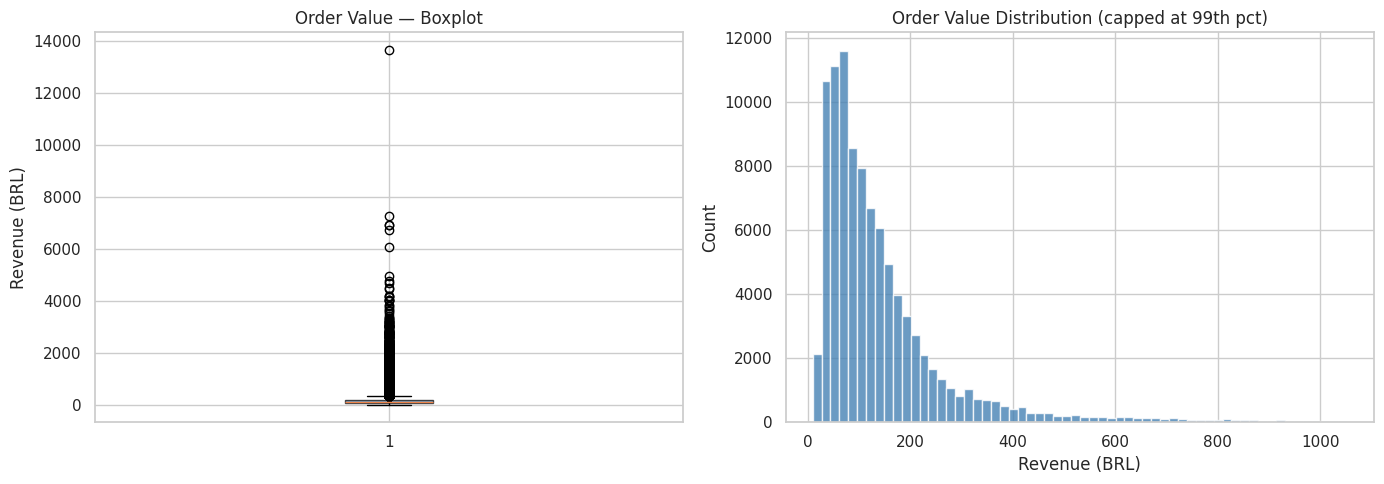


Orders above 3000 BRL: 48 (0.05%)


In [13]:
print('Revenue summary statistics:')
print(tx['revenue'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(tx['revenue'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('Order Value — Boxplot')
axes[0].set_ylabel('Revenue (BRL)')

# Distribution (capped for readability)
cap = tx['revenue'].quantile(0.99)
axes[1].hist(tx[tx['revenue'] <= cap]['revenue'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Order Value Distribution (capped at 99th pct)')
axes[1].set_xlabel('Revenue (BRL)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# How many orders are above 3000 BRL?
extreme = tx[tx['revenue'] > 3000]
print(f'\nOrders above 3000 BRL: {len(extreme)} ({len(extreme)/len(tx)*100:.2f}%)')

**Outlier Treatment**

The transaction value distribution is strongly right-skewed, which is typical in e-commerce environments.

Although a small number of very high-value transactions are present, these observations likely represent legitimate purchases rather than data quality issues.

To avoid underestimating customer value, all transactions are retained. Log transformations are applied where appropriate, while tree-based machine learning models naturally handle extreme values.

## Key Findings

- The overall data quality is high after filtering to delivered orders.
- Customer-level analysis requires the use of `customer_unique_id` to correctly identify repeat purchasers.
- Payment records must be aggregated because a single order can generate multiple payment entries.

## Assumptions

- Delivered orders are treated as completed revenue-generating transactions.
- Payment values accurately represent realized customer spend.
- High-value transactions are retained because they may reflect genuine customer behavior.

---
#B – Exploratory Data Analysis

Before building predictive models, it is important to understand customer purchasing behavior.

This section examines:

- Purchase frequency
- Customer recency
- Spending patterns

These insights provide context for subsequent CLTV modeling and customer segmentation.

## Purchase Frequency Distribution

How many orders does a typical customer make?

Orders per customer summary:
count    93357.000000
mean         1.033420
std          0.209099
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: num_orders, dtype: float64

Customers with exactly 1 order: 90556 (97.0%)
Customers with 2+ orders:       2801 (3.0%)


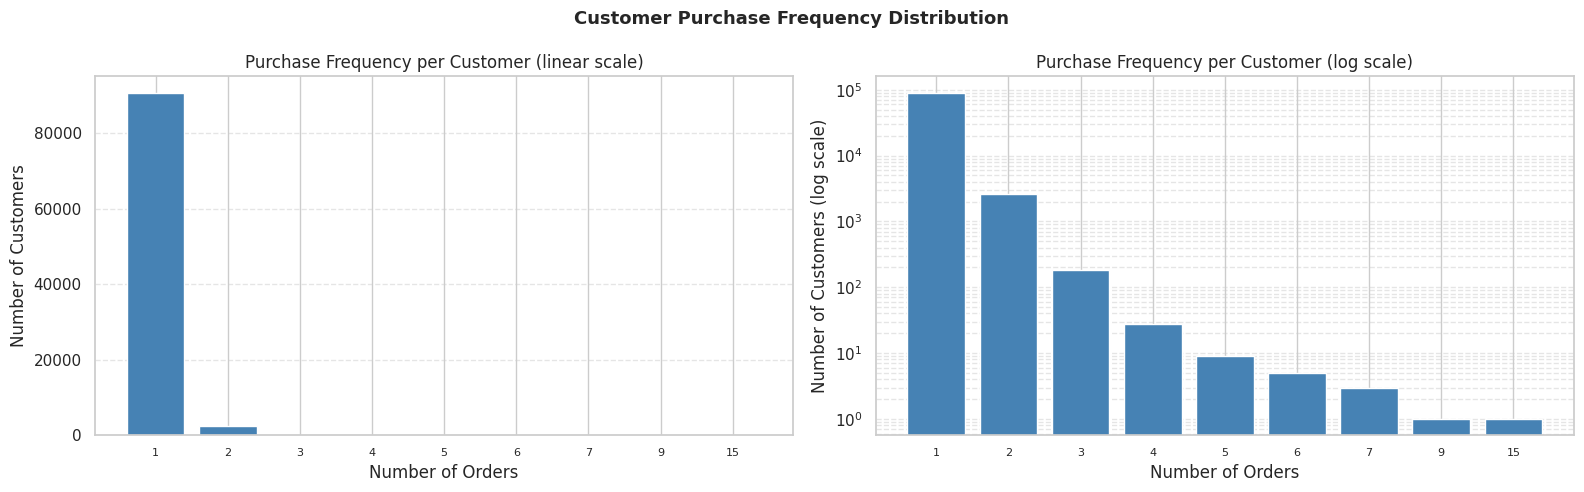

In [14]:
# Orders per customer
order_counts = tx.groupby('customer_unique_id')['purchase_date'].count().rename('num_orders')

print('Orders per customer summary:')
print(order_counts.describe())
print(f'\nCustomers with exactly 1 order: {(order_counts == 1).sum()} ({(order_counts == 1).mean()*100:.1f}%)')
print(f'Customers with 2+ orders:       {(order_counts >= 2).sum()} ({(order_counts >= 2).mean()*100:.1f}%)')

freq_counts = order_counts.value_counts().sort_index()
x_labels = [str(val) if (val <= 10 or val % 5 == 0) else '' for val in freq_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: linear scale ---
axes[0].bar(range(len(freq_counts)), freq_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Purchase Frequency per Customer (linear scale)')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticks(range(len(freq_counts)))
axes[0].set_xticklabels(x_labels, rotation=0, fontsize=8)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[0].set_axisbelow(True)

# --- Right: log scale ---
axes[1].bar(range(len(freq_counts)), freq_counts.values, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Purchase Frequency per Customer (log scale)')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Customers (log scale)')
axes[1].set_xticks(range(len(freq_counts)))
axes[1].set_xticklabels(x_labels, rotation=0, fontsize=8)
axes[1].yaxis.grid(True, which='both', linestyle='--', alpha=0.5)
axes[1].set_axisbelow(True)

plt.suptitle('Customer Purchase Frequency Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation**

The majority of customers made only a single purchase, indicating a strong one-time buyer phenomenon.

This pattern is common in e-commerce and highlights the importance of retention strategies. A relatively small group of repeat customers is likely responsible for a disproportionate share of future revenue.

## Recency Distribution

Recency = days since the customer's last purchase (relative to the observation end date).

Observation end date: 2018-08-29 15:00:37

Recency (days since last purchase) summary:
count    93357.000000
mean       236.936673
std        152.584315
min          0.000000
25%        113.000000
50%        218.000000
75%        345.000000
max        694.000000
Name: purchase_date, dtype: float64


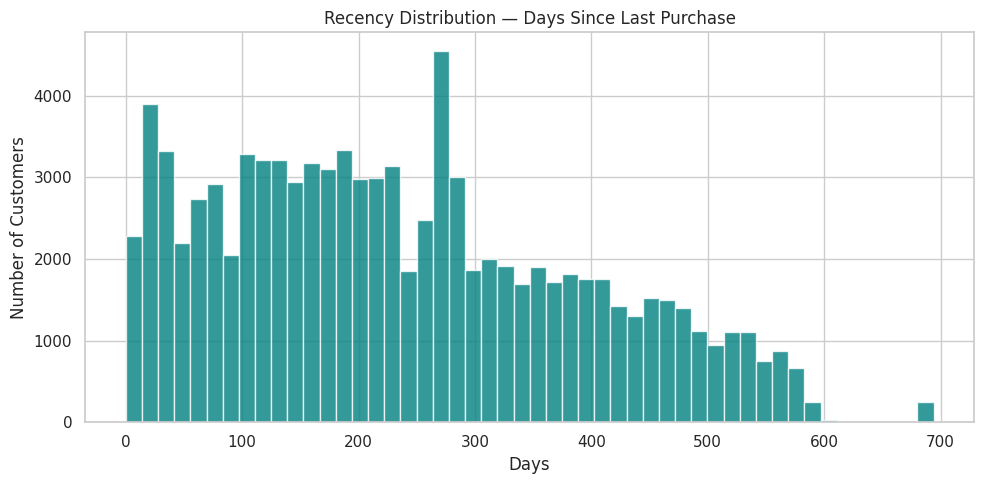

In [15]:
# Define the observation end date as the last transaction date in the dataset
obs_end = tx['purchase_date'].max()
print(f'Observation end date: {obs_end}')

# Last purchase per customer
last_purchase = tx.groupby('customer_unique_id')['purchase_date'].max()
recency_days = (obs_end - last_purchase).dt.days

print(f'\nRecency (days since last purchase) summary:')
print(recency_days.describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(recency_days, bins=50, color='teal', edgecolor='white', alpha=0.8)
ax.set_title('Recency Distribution — Days Since Last Purchase')
ax.set_xlabel('Days')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Interpretation**

Customer recency varies considerably across the dataset.

Customers with high recency values have not purchased recently and are more likely to have churned, while recently active customers are more likely to remain engaged. This behavior is directly captured by the BG/NBD model through its probability-of-being-alive estimates.

## Monetary Value Distribution

How much does a typical customer spend?

Total customer spend summary:
count    93357.000000
mean       165.198772
std        226.314579
min          9.590000
25%         63.060000
50%        107.780000
75%        182.560000
90%        318.082000
95%        469.622000
max      13664.080000
Name: revenue, dtype: float64


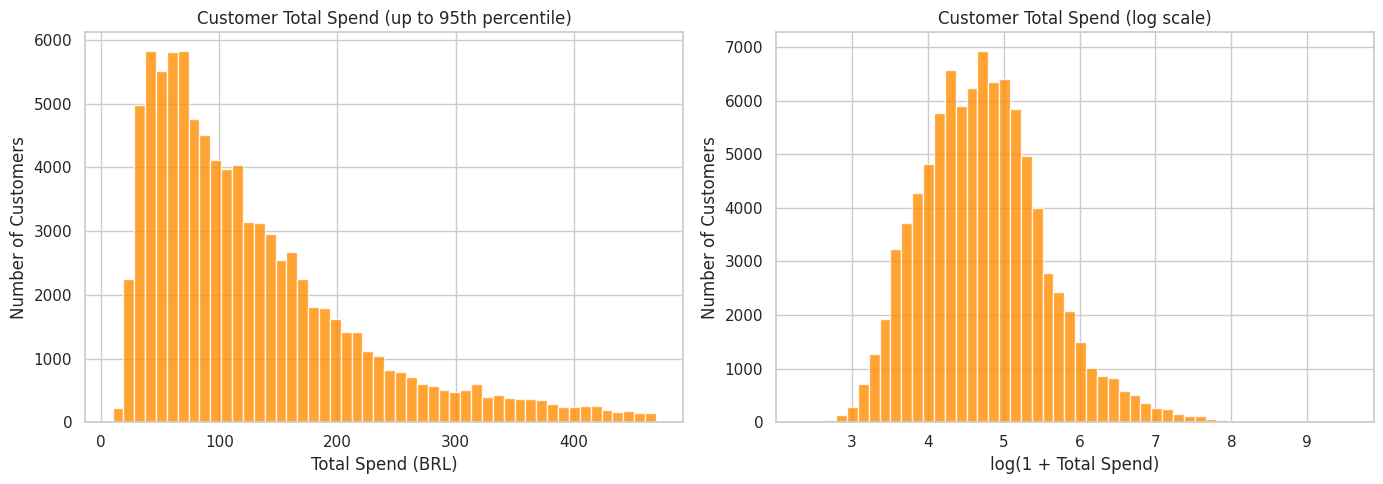

In [16]:
# Total spend per customer
total_spend = tx.groupby('customer_unique_id')['revenue'].sum()

print('Total customer spend summary:')
print(total_spend.describe(percentiles=[.25, .5, .75, .90, .95]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular histogram (capped)
cap = total_spend.quantile(0.95)
axes[0].hist(total_spend[total_spend <= cap], bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[0].set_title('Customer Total Spend (up to 95th percentile)')
axes[0].set_xlabel('Total Spend (BRL)')
axes[0].set_ylabel('Number of Customers')

# Log-transformed
axes[1].hist(np.log1p(total_spend), bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Customer Total Spend (log scale)')
axes[1].set_xlabel('log(1 + Total Spend)')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

**Interpretation**

Customer spending follows a right-skewed distribution, with most customers generating moderate revenue and a small number contributing substantially larger amounts.

The log-transformed distribution appears considerably more symmetric, supporting the assumptions required for Gamma-Gamma modeling.

## Customer Retention Insights

One-time buyers:   90,556 (97.0%)
Repeat buyers:     2,801 (3.0%)

Revenue from one-time buyers: 94.4%
Revenue from repeat buyers:   5.6%


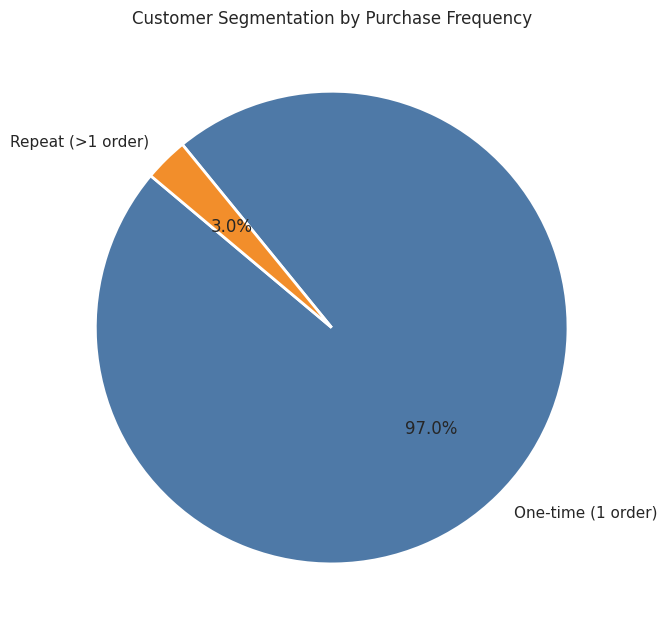

In [17]:
# Segment customers by number of orders
one_time = (order_counts == 1).sum()
repeat   = (order_counts >= 2).sum()

print(f'One-time buyers:   {one_time:,} ({one_time/len(order_counts)*100:.1f}%)')
print(f'Repeat buyers:     {repeat:,} ({repeat/len(order_counts)*100:.1f}%)')

# Revenue contribution
customer_spend = tx.groupby('customer_unique_id')['revenue'].sum()
customer_orders_merged = pd.DataFrame({'spend': customer_spend, 'orders': order_counts})

revenue_one_time = customer_orders_merged[customer_orders_merged['orders'] == 1]['spend'].sum()
revenue_repeat   = customer_orders_merged[customer_orders_merged['orders'] >= 2]['spend'].sum()
total_rev = customer_orders_merged['spend'].sum()

print(f'\nRevenue from one-time buyers: {revenue_one_time/total_rev*100:.1f}%')
print(f'Revenue from repeat buyers:   {revenue_repeat/total_rev*100:.1f}%')

# Pie chart
fig, ax = plt.subplots(figsize=(7, 7))
sizes = [one_time, repeat]
labels = ['One-time (1 order)', 'Repeat (>1 order)']
colors = ['#4e79a7', '#f28e2b'] # Adjusted to match the 2 categories
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Customer Segmentation by Purchase Frequency')
plt.tight_layout()
plt.show()

**Interpretation**

The analysis confirms that repeat purchasers represent a minority of the customer base.

Despite their limited number, these customers are expected to contribute a substantial portion of future revenue. This reinforces the importance of CLTV modeling as a tool for prioritizing retention and loyalty initiatives.

# RFM Feature Engineering

The customer-level dataset is transformed into four key behavioral metrics:

- **Recency (R):** Time between the customer's most recent purchase and the observation end date.
- **Frequency (F):** Number of repeat purchases.
- **Monetary Value (M):** Average transaction value.
- **T (Customer Tenure):** Time between the customer's first purchase and the observation end date.

These variables form the foundation of the BTYD modeling framework.

In [18]:
# Use the lifetimes utility function to compute RFM + T in one step
# 'observation_period_end' is the last date in our dataset
# 'monetary_value' will be the average transaction value (not total)

rfm_table = summary_data_from_transaction_data(
    tx,
    customer_id_col='customer_unique_id',
    datetime_col='purchase_date',
    monetary_value_col='revenue',
    observation_period_end=obs_end,
    freq='D'   # daily time units
)

print('RFM table shape:', rfm_table.shape)
print('\nColumn descriptions:')
print('  frequency:       number of REPEAT purchases (total purchases - 1)')
print('  recency:         days between first and LAST purchase')
print('  T:               days between first purchase and observation end')
print('  monetary_value:  average transaction value (repeat purchases only)')
print()
print(rfm_table.describe().round(2))

RFM table shape: (93357, 4)

Column descriptions:
  frequency:       number of REPEAT purchases (total purchases - 1)
  recency:         days between first and LAST purchase
  T:               days between first purchase and observation end
  monetary_value:  average transaction value (repeat purchases only)

       frequency   recency         T  monetary_value
count   93357.00  93357.00  93357.00        93357.00
mean        0.02      2.65    240.12            3.26
std         0.18     25.01    153.10           32.21
min         0.00      0.00      0.00            0.00
25%         0.00      0.00    116.00            0.00
50%         0.00      0.00    221.00            0.00
75%         0.00      0.00    350.00            0.00
max        14.00    633.00    695.00         2405.28


In [19]:
# The Gamma-Gamma model requires customers with at least 1 repeat purchase
# We also need monetary_value > 0 for both models
print(f'Customers in RFM table: {len(rfm_table)}')
print(f'Customers with frequency > 0 (repeat buyers): {(rfm_table["frequency"] > 0).sum()}')
print(f'Customers with monetary_value > 0: {(rfm_table["monetary_value"] > 0).sum()}')

Customers in RFM table: 93357
Customers with frequency > 0 (repeat buyers): 2015
Customers with monetary_value > 0: 2015


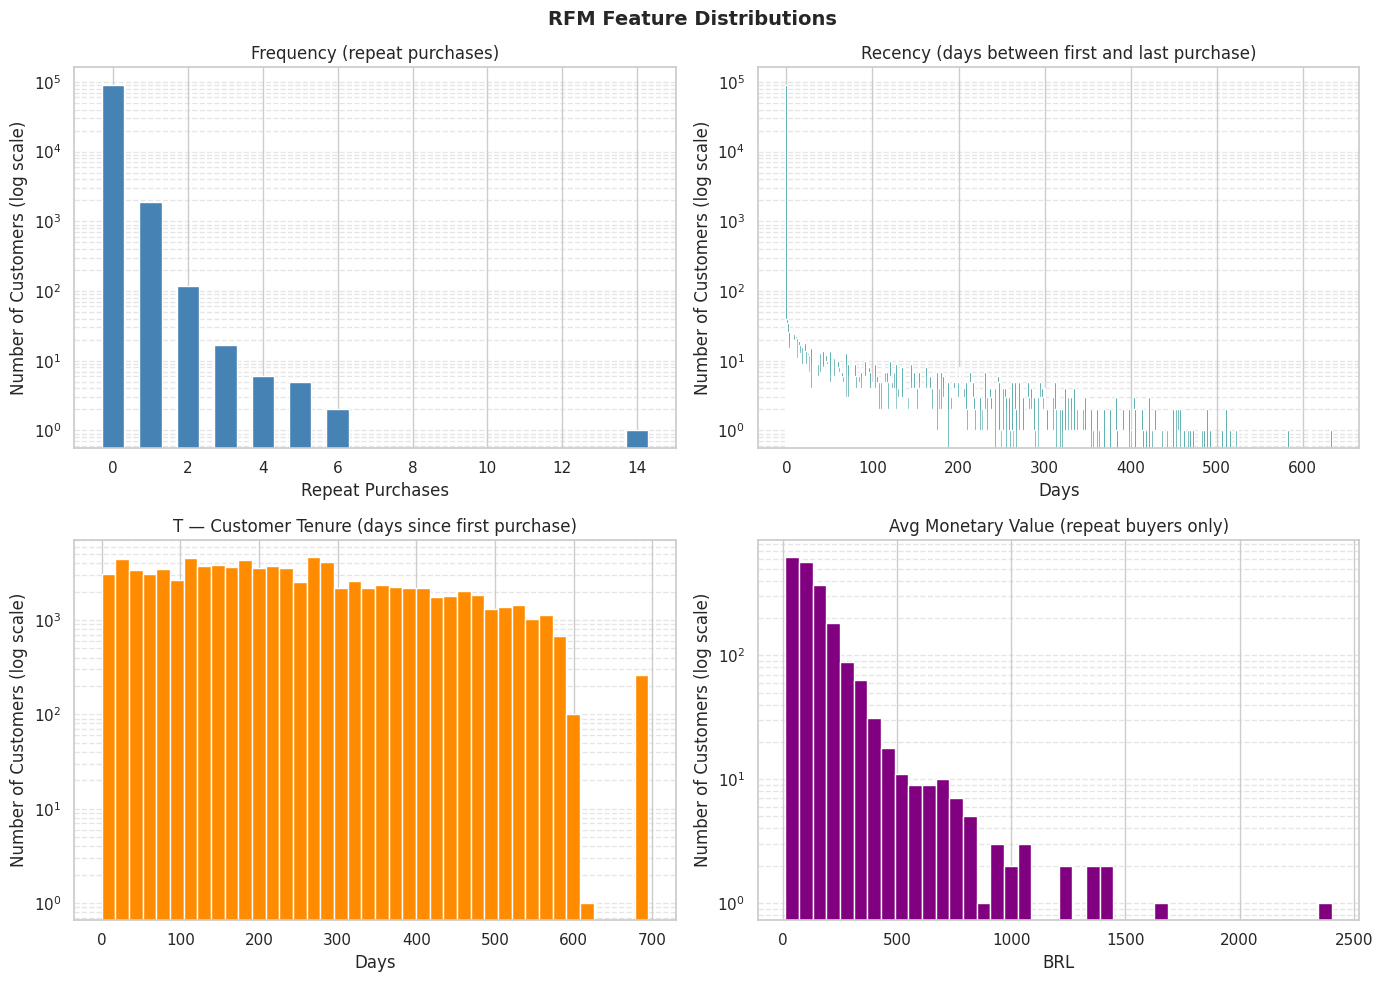

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rfm_plot = rfm_table.copy()

# --- Frequency (log scale) ---
freq_counts = rfm_plot['frequency'].value_counts().sort_index()
axes[0,0].bar(freq_counts.index, freq_counts.values, color='steelblue', edgecolor='white', width=0.6)
axes[0,0].set_yscale('log')
axes[0,0].set_title('Frequency (repeat purchases)')
axes[0,0].set_xlabel('Repeat Purchases')
axes[0,0].set_ylabel('Number of Customers (log scale)')
axes[0,0].yaxis.grid(True, which='both', linestyle='--', alpha=0.5)
axes[0,0].set_axisbelow(True)

# --- Recency (log scale) ---
recency_counts = rfm_plot['recency'].value_counts().sort_index()
axes[0,1].bar(recency_counts.index, recency_counts.values, color='teal', edgecolor='white', width=2)
axes[0,1].set_yscale('log')
axes[0,1].set_title('Recency (days between first and last purchase)')
axes[0,1].set_xlabel('Days')
axes[0,1].set_ylabel('Number of Customers (log scale)')
axes[0,1].yaxis.grid(True, which='both', linestyle='--', alpha=0.5)
axes[0,1].set_axisbelow(True)

# --- T / Tenure (log scale) ---
rfm_plot['T'].hist(bins=40, ax=axes[1,0], color='darkorange', edgecolor='white')
axes[1,0].set_yscale('log')
axes[1,0].set_title('T — Customer Tenure (days since first purchase)')
axes[1,0].set_xlabel('Days')
axes[1,0].set_ylabel('Number of Customers (log scale)')
axes[1,0].yaxis.grid(True, which='both', linestyle='--', alpha=0.5)
axes[1,0].set_axisbelow(True)

# --- Monetary Value (log scale) ---
mv = rfm_plot[rfm_plot['frequency'] > 0]['monetary_value']
mv.hist(bins=40, ax=axes[1,1], color='purple', edgecolor='white')
axes[1,1].set_yscale('log')
axes[1,1].set_title('Avg Monetary Value (repeat buyers only)')
axes[1,1].set_xlabel('BRL')
axes[1,1].set_ylabel('Number of Customers (log scale)')
axes[1,1].yaxis.grid(True, which='both', linestyle='--', alpha=0.5)
axes[1,1].set_axisbelow(True)

plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**

**Frequency:** The drop-off is dramatic and exponential. The vast majority of customers made 0 repeat purchases, meaning they bought exactly once and never came back. Repeat buyers are rare but exist, up to 14 repeat purchases in the dataset.

**Recency:** Most customers have a recency of 0 days, meaning their first and last purchase are the same event (one-time buyers). For the small group of repeat buyers, recency spreads across the full 600+ day window, with a clear exponential decay, customers who came back multiple times tended to do so within the first 100 days.

**Customer Tenure / T:** This is much more evenly distributed than the other features, customers joined Olist at different points throughout the 2 year observation window. The slight drop at the very end (~600-700 days) is expected since those are the most recently acquired customers who had less time to generate transactions.

**Avg Monetary Value:** Repeat buyers tend to spend between 50 and 300 BRL per transaction on average, with a long tail up to ~2500 BRL. The distribution is right-skewed but reasonable, most repeat customers are moderate spenders, and the few high-value outliers are likely purchasing electronics or furniture. This shape is consistent with the Gamma-Gamma model assumptions.

---
#C – Modeling & Evaluation

Two complementary approaches are used to estimate customer value:

1. **Probabilistic Modeling (BTYD)**  
   Estimates future purchasing behavior and customer survival probability.

2. **Machine Learning Modeling**  
   Predicts holdout-period revenue using customer-level features.

The performance and business applicability of both approaches are evaluated and compared.

## Calibration / Holdout Split

To evaluate how well the models predict future customer behavior, the observation window is split into two time-based periods:

* **Calibration period:** all transactions before the final 90 days of the dataset. This period is used to train the BTYD and machine learning models.
* **Holdout period:** the final 90 days of the dataset. This period is used to compare predicted revenue with the actual revenue generated by customers during the same 90-day horizon.

This setup is consistent with the project objective of estimating 90-day CLTV, because the prediction horizon and the evaluation period have the same length.


In [21]:
# Define calibration / holdout cut-off date
# The final 90 days of the dataset are used as the holdout period.
# This aligns the evaluation window with the required 90-day CLTV prediction.

obs_start = tx['purchase_date'].min()
obs_end_full = tx['purchase_date'].max()

# 90-day holdout period
holdout_days = 90
calibration_end = obs_end_full - pd.Timedelta(days=holdout_days)

# Calculate window lengths
total_days = (obs_end_full - obs_start).days
calibration_days = (calibration_end - obs_start).days

print(f'Observation window : {obs_start.date()} → {obs_end_full.date()} ({total_days} days)')
print(f'Calibration period : {obs_start.date()} → {calibration_end.date()} ({calibration_days} days)')
print(f'Holdout period     : {(calibration_end + pd.Timedelta(days=1)).date()} → {obs_end_full.date()} ({holdout_days} days)')


Observation window : 2016-10-03 → 2018-08-29 (695 days)
Calibration period : 2016-10-03 → 2018-05-31 (605 days)
Holdout period     : 2018-06-01 → 2018-08-29 (90 days)


**Split logic:** A time-based split ensures that the models are trained only on historical transactions and evaluated on genuinely unseen future behavior. The final 90 days of the dataset are reserved as the holdout period, which aligns the evaluation window with the required 90-day CLTV prediction. A random split would not be appropriate because it could leak future customer behavior into the training data.

In [22]:
# Build calibration + holdout RFM table using the lifetimes utility.
# The function aggregates transaction-level data into customer-level BTYD features.

cal_hol = calibration_and_holdout_data(
    tx,
    customer_id_col='customer_unique_id',
    datetime_col='purchase_date',
    monetary_value_col='revenue',
    calibration_period_end=calibration_end,
    observation_period_end=obs_end_full,
    freq='D'
)

print('Calibration + holdout table shape:', cal_hol.shape)
print()
print('Column reference:')
print('  frequency_cal       — repeat purchases during calibration')
print('  recency_cal         — days between first and last purchase in calibration')
print('  T_cal               — customer tenure at end of calibration')
print('  monetary_value_cal  — average transaction value during calibration')
print('  frequency_holdout   — actual repeat purchases during holdout')
print('  duration_holdout    — length of the holdout window in days')
print()
print(cal_hol.describe().round(2))


Calibration + holdout table shape: (75319, 7)

Column reference:
  frequency_cal       — repeat purchases during calibration
  recency_cal         — days between first and last purchase in calibration
  T_cal               — customer tenure at end of calibration
  monetary_value_cal  — average transaction value during calibration
  frequency_holdout   — actual repeat purchases during holdout
  duration_holdout    — length of the holdout window in days

       frequency_cal  recency_cal     T_cal  monetary_value_cal  \
count       75319.00     75319.00  75319.00            75319.00   
mean            0.02         2.12    196.98                2.98   
std             0.17        20.87    132.42               29.77   
min             0.00         0.00      0.00                0.00   
25%             0.00         0.00     87.00                0.00   
50%             0.00         0.00    179.00                0.00   
75%             0.00         0.00    294.00                0.00   
max    

**Output:** Each row is one customer. `frequency_cal` counts *repeat* purchases (first purchase excluded), so one-time buyers have `frequency_cal = 0`. `monetary_value_cal` is the *average* transaction value as required by the Gamma-Gamma model.

## BG/NBD Model

The **Beta-Geometric / Negative Binomial Distribution (BG/NBD)** model estimates:

- **Expected number of future transactions** — how many times a customer will buy again.
- **Probability of being alive** — whether the customer is still active or has churned.

The model requires customers with at least one observed transaction. It is fit exclusively on calibration-period RFM data.


In [23]:
# Fit the BG/NBD model on calibration data only.
# The model uses daily time units because recency_cal and T_cal are measured in days.

bgf = BetaGeoFitter(penalizer_coef=0.01)

bgf.fit(
    cal_hol['frequency_cal'],
    cal_hol['recency_cal'],
    cal_hol['T_cal']
)

print('Estimated parameters:')
print(bgf.summary)


Estimated parameters:
            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.016656  0.000968         0.014759         0.018553
alpha  69.320612  6.659174        56.268630        82.372593
a       0.086976  0.020712         0.046381         0.127571
b       0.016486  0.004220         0.008214         0.024758


**Parameters:** The BG/NBD model estimates four parameters — `r`, `alpha` (purchase rate heterogeneity) and `a`, `b` (dropout probability heterogeneity). A penalizer of 0.01 prevents overfitting on the long tail of high-frequency buyers.

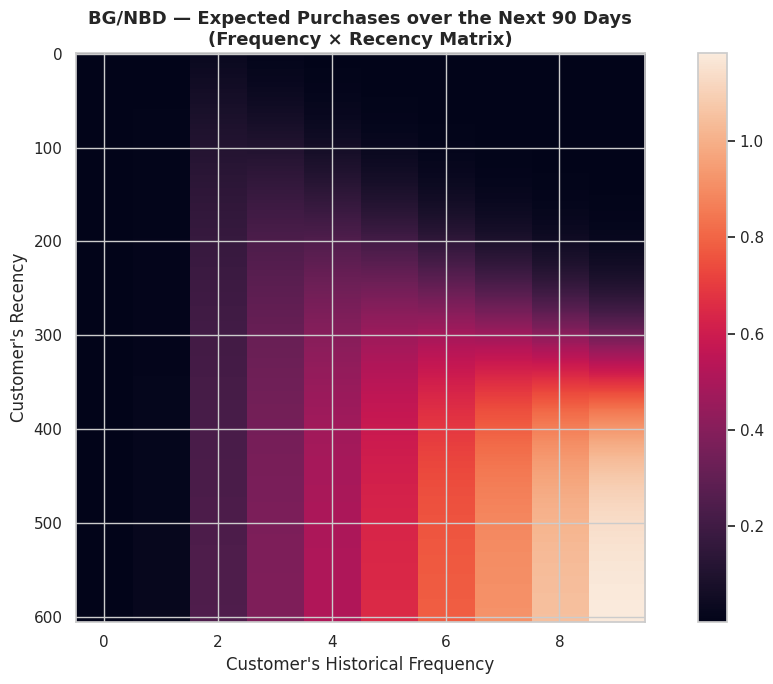

In [24]:
# Visual 1 — Frequency / Recency matrix
# The plot shows the expected number of purchases over the next 90 days
# based on each customer's frequency and recency patterns.

fig = plt.figure(figsize=(11, 7))
plot_frequency_recency_matrix(bgf, T=90)

plt.title(
    'BG/NBD — Expected Purchases over the Next 90 Days\n(Frequency × Recency Matrix)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Interpretation: Expected future purchases increase with both historical frequency and recency. Customers who purchased repeatedly and remained active for longer are predicted to make the most future purchases.

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

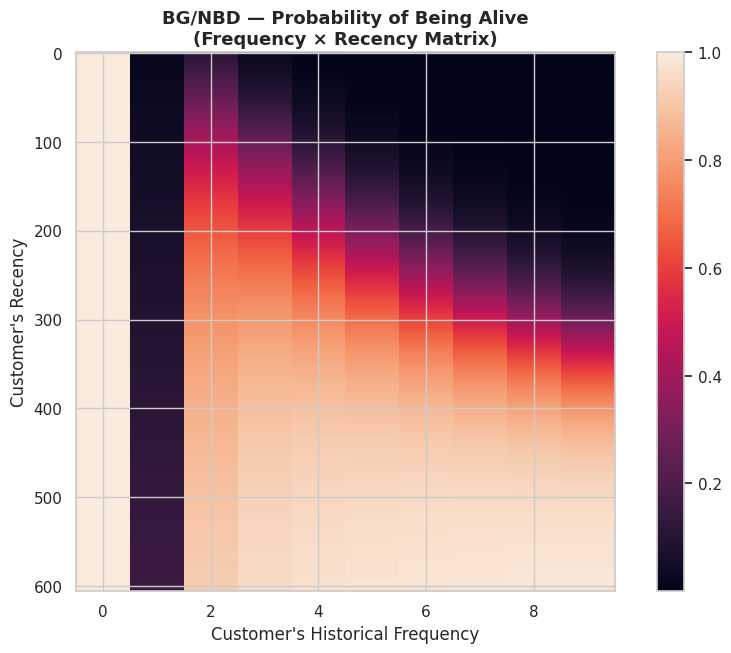

In [25]:
# Visual 2 — Probability Alive matrix
# The plot shows the estimated probability that a customer is still active
# based on their purchase frequency and recency patterns.

fig = plt.figure(figsize=(11, 7))

plot_probability_alive_matrix(bgf)

plt.title(
    'BG/NBD — Probability of Being Alive\n(Frequency × Recency Matrix)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout


Interpretation: Among repeat buyers, the probability of being active increases when purchases extend further into the customer’s observed lifetime. Customers with several purchases concentrated early in the period are more likely to have churned

<Figure size 1000x500 with 0 Axes>

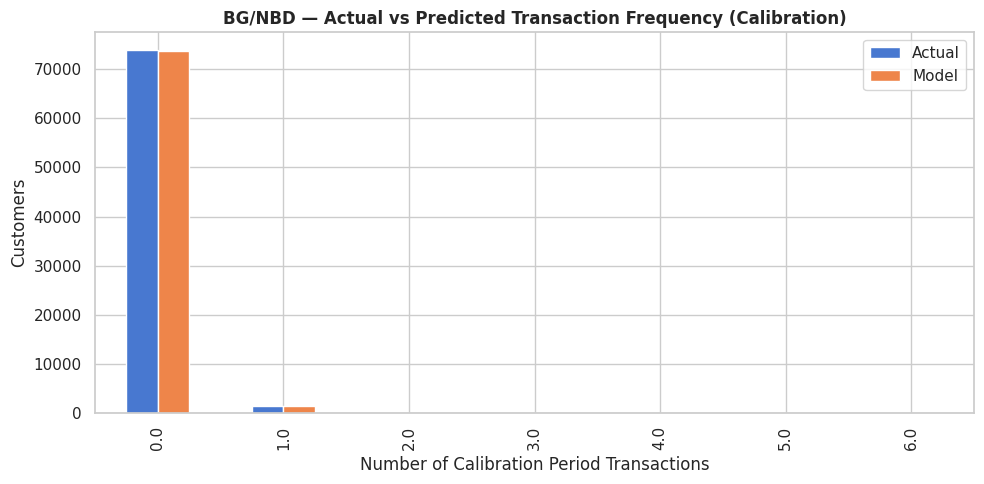

In [26]:
# Visual 3 — Actual vs model-predicted transaction frequency
# This diagnostic plot compares the distribution of actual repeat purchases
# with the distribution expected by the BG/NBD model during the calibration period.

fig = plt.figure(figsize=(10, 5))

plot_period_transactions(bgf)

plt.title(
    'BG/NBD — Actual vs Predicted Transaction Frequency (Calibration)',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


Interpretation: The predicted distribution closely matches the observed calibration data, particularly for customers with zero or one repeat purchase. This suggests that BG/NBD captures the overall purchase-frequency pattern.

In [27]:
# Predict expected purchases during the holdout window for each customer
holdout_days = (obs_end_full - calibration_end).days
print(f'Holdout duration: {holdout_days} days')

#expected number of repeat purchases during the 90-day holdout period
cal_hol['predicted_purchases_bgf'] = bgf.predict(
    holdout_days,
    cal_hol['frequency_cal'],
    cal_hol['recency_cal'],
    cal_hol['T_cal']
)

# Probability that each customer is still alive at end of calibration
cal_hol['prob_alive'] = bgf.conditional_probability_alive(
    cal_hol['frequency_cal'],
    cal_hol['recency_cal'],
    cal_hol['T_cal']
)

print('Holdout prediction summary:')
print(cal_hol[['predicted_purchases_bgf', 'frequency_holdout', 'prob_alive']].describe().round(3))



Holdout duration: 90 days
Holdout prediction summary:
       predicted_purchases_bgf  frequency_holdout  prob_alive
count                75319.000          75319.000   75319.000
mean                     0.007              0.006       0.983
std                      0.025              0.081       0.123
min                      0.002              0.000       0.019
25%                      0.004              0.000       1.000
50%                      0.005              0.000       1.000
75%                      0.008              0.000       1.000
max                      1.905              5.000       1.000


The BG/NBD model predicts a very low average number of purchases during the 90-day holdout period. This is consistent with the actual holdout behavior, where most customers did not make any repeat purchase. The predicted average purchase frequency is close to the observed holdout frequency, suggesting that the model captures the overall low-repeat-purchase pattern of the dataset.

The probability alive values are generally high, but this should not be interpreted as a high probability of immediate repurchase. In the BG/NBD framework, a customer may still be considered active while having a very low expected number of future transactions.

## Gamma-Gamma Model

The **Gamma-Gamma** model estimates the average monetary value per transaction for each customer.

**Key assumption:** monetary value and purchase frequency must be independent.  
We verify this with a correlation check before fitting.

The model is trained only on repeat buyers (`frequency_cal > 0`), because Gamma-Gamma estimates average transaction value using customers with repeated purchase behavior. For one-time customers, the model is not directly applicable, so a fallback based on their observed calibration order value is used later.

In [28]:
# Check Gamma-Gamma assumption: purchase frequency and average monetary value
# should be approximately independent among repeat buyers.

repeat_mask = cal_hol['frequency_cal'] > 0
freq_mv_corr = cal_hol.loc[repeat_mask, ['frequency_cal', 'monetary_value_cal']].corr().iloc[0, 1]
print(f'Pearson correlation (frequency vs monetary_value) on repeat buyers: {freq_mv_corr:.4f}')

if abs(freq_mv_corr) < 0.20:
    print('Correlation is low — Gamma-Gamma independence assumption is satisfied.')
else:
    print('Correlation exceeds 0.20 — interpret Gamma-Gamma results with caution.')


Pearson correlation (frequency vs monetary_value) on repeat buyers: 0.0053
Correlation is low — Gamma-Gamma independence assumption is satisfied.


 The Gamma-Gamma model assumes spend and frequency are independent — high-frequency buyers should not systematically spend more or less per transaction. A Pearson correlation above 0.20 would bias CLTV estimates upward.

In [29]:
# Fit the Gamma-Gamma model on calibration repeat buyers only.
# Gamma-Gamma estimates the expected average transaction value for customers
# with at least one repeat purchase in the calibration period.

gg_data = cal_hol[cal_hol['frequency_cal'] > 0].copy()

print(f'Number of customers used for Gamma-Gamma fitting: {gg_data.shape[0]}')

ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(
    gg_data['frequency_cal'],
    gg_data['monetary_value_cal']
)

print('Estimated parameters:')
print(ggf.summary)


Number of customers used for Gamma-Gamma fitting: 1502
Estimated parameters:
       coef  se(coef)  lower 95% bound  upper 95% bound
p  4.123633  0.128469         3.871833         4.375433
q  0.497048  0.015172         0.467311         0.526785
v  3.850130  0.129588         3.596138         4.104122


**Parameters:** The Gamma-Gamma model estimates `p`, `q`, `v` — shape parameters of the Gamma distribution over individual average transaction values. It shrinks each customer's observed average toward the population mean, which is especially valuable for customers with few repeat purchases.

In [30]:
# Predict conditional expected average transaction value for repeat buyers only.
# Gamma-Gamma is applied only to customers with at least one repeat purchase
# in the calibration period.

gg_data = cal_hol[cal_hol['frequency_cal'] > 0].copy()

gg_data['predicted_avg_value'] = ggf.conditional_expected_average_profit(
    gg_data['frequency_cal'],
    gg_data['monetary_value_cal']
)

# Remove the column if it already exists, so the cell can be safely re-run.
if 'predicted_avg_value' in cal_hol.columns:
    cal_hol = cal_hol.drop(columns=['predicted_avg_value'])

# Add Gamma-Gamma predictions back to the main customer-level table.
cal_hol = cal_hol.join(
    gg_data[['predicted_avg_value']],
    how='left'
)

# For customers who are not eligible for Gamma-Gamma, use their observed
# average order value from the calibration period as a simple fallback.
calibration_tx = tx[tx['purchase_date'] <= calibration_end].copy()

observed_avg_value_cal = (
    calibration_tx
    .groupby('customer_unique_id')['revenue']
    .mean()
    .rename('observed_avg_value_cal')
)

cal_hol = cal_hol.join(observed_avg_value_cal, how='left')

cal_hol['predicted_avg_value'] = cal_hol['predicted_avg_value'].fillna(
    cal_hol['observed_avg_value_cal']
)

print('Predicted average transaction value summary:')
print(cal_hol['predicted_avg_value'].describe().round(2))


Predicted average transaction value summary:
count    75319.00
mean       160.10
std        216.74
min         10.07
25%         62.28
50%        105.31
75%        176.71
max      13664.08
Name: predicted_avg_value, dtype: float64


The Gamma-Gamma model was used to estimate the expected average transaction value for repeat buyers only. Since the model is not applicable to one-time customers, their observed average order value during the calibration period was used as a fallback. This allows all customers to receive a predicted average value before calculating BTYD-based 90-day revenue.

## 90-Day CLTV Prediction (BTYD)

We combine the BG/NBD purchase-count predictions with the Gamma-Gamma average-value estimates to produce a **90-day Customer Lifetime Value** for every customer.

CLTV is estimated using the  library's  function, which internally applies a discount rate to account for the time value of money.


In [31]:
# Compute 90-day BTYD predicted revenue
# BG/NBD predicts the expected number of purchases during the 90-day holdout period.
# Gamma-Gamma / fallback average value estimates the expected transaction value.
# Predicted revenue = expected purchases × expected average transaction value.

cal_hol['cltv_90_btyd'] = (
    cal_hol['predicted_purchases_bgf'] * cal_hol['predicted_avg_value']
)

# CLTV cannot be negative
cal_hol['cltv_90_btyd'] = cal_hol['cltv_90_btyd'].clip(lower=0)

print('90-day BTYD predicted revenue summary:')
print(cal_hol['cltv_90_btyd'].describe().round(2))

print(f'\nTotal predicted 90-day BTYD revenue: BRL {cal_hol["cltv_90_btyd"].sum():,.2f}')



90-day BTYD predicted revenue summary:
count    75319.00
mean         1.22
std          5.54
min          0.04
25%          0.32
50%          0.59
75%          1.15
max        688.88
Name: cltv_90_btyd, dtype: float64

Total predicted 90-day BTYD revenue: BRL 91,686.69


In [32]:
# Calculate actual revenue generated during the 90-day holdout period
holdout_tx = tx[
    (tx['purchase_date'] > calibration_end) &
    (tx['purchase_date'] <= obs_end_full)
].copy()

actual_holdout_revenue = (
    holdout_tx
    .groupby('customer_unique_id')['revenue']
    .sum()
    .rename('actual_revenue_holdout')
)

# Add actual holdout revenue to cal_hol
if 'actual_revenue_holdout' in cal_hol.columns:
    cal_hol = cal_hol.drop(columns=['actual_revenue_holdout'])

cal_hol = cal_hol.join(actual_holdout_revenue, how='left')
cal_hol['actual_revenue_holdout'] = cal_hol['actual_revenue_holdout'].fillna(0)

print('Actual 90-day holdout revenue summary:')
print(cal_hol['actual_revenue_holdout'].describe().round(2))

print(f'\nTotal actual 90-day holdout revenue: BRL {cal_hol["actual_revenue_holdout"].sum():,.2f}')
print(f'Total predicted 90-day BTYD revenue: BRL {cal_hol["cltv_90_btyd"].sum():,.2f}')

Actual 90-day holdout revenue summary:
count    75319.00
mean         0.89
std         18.12
min          0.00
25%          0.00
50%          0.00
75%          0.00
max       1596.96
Name: actual_revenue_holdout, dtype: float64

Total actual 90-day holdout revenue: BRL 67,140.30
Total predicted 90-day BTYD revenue: BRL 91,686.69


Customers with CLTV > 0: 75319 (100.0%)
count    75319.00
mean         1.22
std          5.54
min          0.04
25%          0.32
50%          0.59
75%          1.15
max        688.88
Name: cltv_90_btyd, dtype: float64


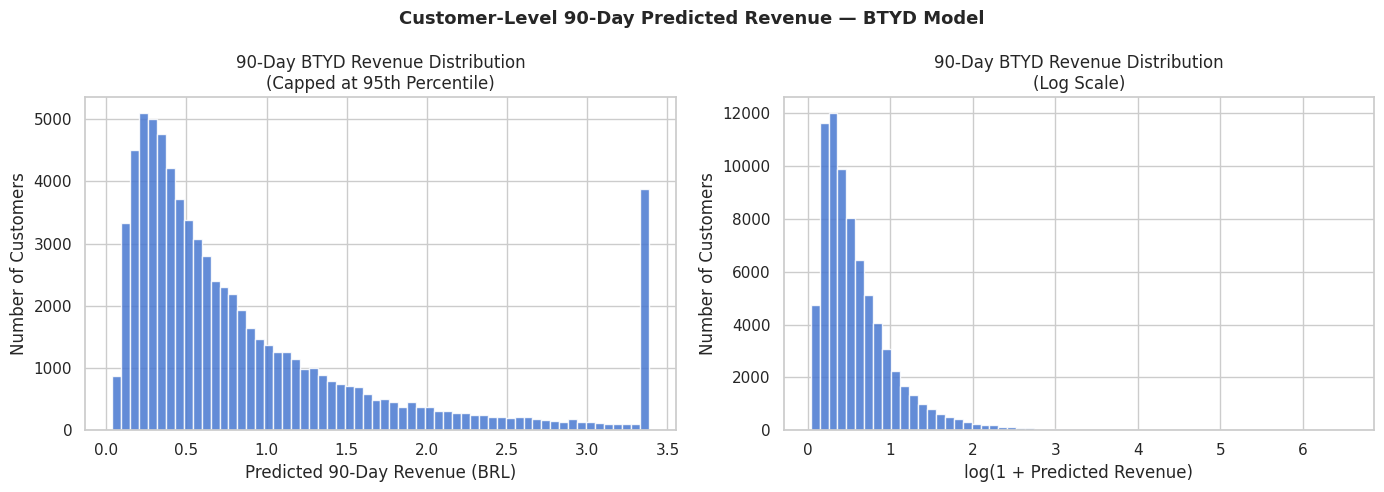

In [33]:
# Plot customers with positive predicted 90-day BTYD revenue
# The distribution is highly right-skewed, so we show both a capped version
# and a log-transformed version for readability.

positive_cltv = cal_hol[cal_hol['cltv_90_btyd'] > 0]['cltv_90_btyd']

print(f'Customers with CLTV > 0: {len(positive_cltv)} ({len(positive_cltv) / len(cal_hol) * 100:.1f}%)')
print(positive_cltv.describe().round(2))

cap = positive_cltv.quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    positive_cltv.clip(upper=cap),
    bins=60,
    edgecolor='white',
    alpha=0.85
)
axes[0].set_title('90-Day BTYD Revenue Distribution\n(Capped at 95th Percentile)')
axes[0].set_xlabel('Predicted 90-Day Revenue (BRL)')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(
    np.log1p(positive_cltv),
    bins=60,
    edgecolor='white',
    alpha=0.85
)
axes[1].set_title('90-Day BTYD Revenue Distribution\n(Log Scale)')
axes[1].set_xlabel('log(1 + Predicted Revenue)')
axes[1].set_ylabel('Number of Customers')

plt.suptitle(
    'Customer-Level 90-Day Predicted Revenue — BTYD Model',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

The BTYD model assigns a positive predicted 90-day revenue to all customers because BG/NBD produces probabilistic expected purchase values rather than hard zero/one predictions. However, most predicted values are extremely low. The median predicted 90-day revenue is below BRL 1, indicating that the majority of customers are unlikely to generate meaningful short-term revenue. The distribution is strongly right-skewed, with a small group of customers having substantially higher predicted value. For readability, the first histogram is capped at the 95th percentile, while the second uses a log transformation.

Total customers included: 75,319


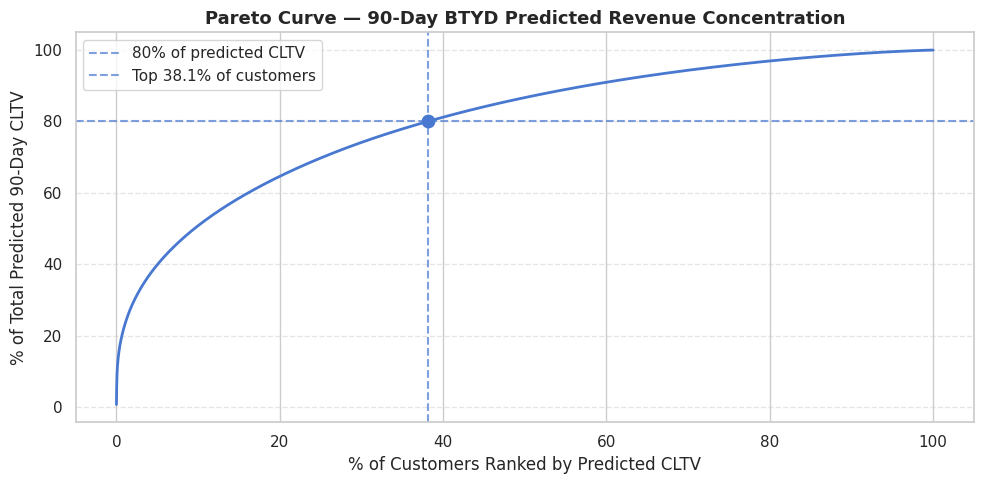

Top 38.1% of customers drive 80% of predicted 90-day BTYD revenue.
This corresponds to approximately 28,694 customers out of 75,319.


In [34]:
# Pareto curve for customer-level 90-day BTYD predicted revenue.
# Customers are ranked from highest to lowest predicted value to assess
# how concentrated the predicted revenue is within the customer base.

cltv_sorted = cal_hol['cltv_90_btyd'].sort_values(ascending=False)

print(f'Total customers included: {len(cltv_sorted):,}')

cumulative_cltv = cltv_sorted.cumsum() / cltv_sorted.sum() * 100
cumulative_customers = np.arange(1, len(cltv_sorted) + 1) / len(cltv_sorted) * 100

idx_80 = np.searchsorted(cumulative_cltv.values, 80)
pct_customers_80 = cumulative_customers[idx_80]
n_customers_80 = idx_80 + 1

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    cumulative_customers,
    cumulative_cltv.values,
    linewidth=2
)

ax.axhline(
    80,
    linestyle='--',
    linewidth=1.5,
    alpha=0.7,
    label='80% of predicted CLTV'
)

ax.axvline(
    pct_customers_80,
    linestyle='--',
    linewidth=1.5,
    alpha=0.7,
    label=f'Top {pct_customers_80:.1f}% of customers'
)

ax.scatter(
    [pct_customers_80],
    [80],
    s=80,
    zorder=5
)

ax.set_xlabel('% of Customers Ranked by Predicted CLTV')
ax.set_ylabel('% of Total Predicted 90-Day CLTV')

ax.set_title(
    'Pareto Curve — 90-Day BTYD Predicted Revenue Concentration',
    fontsize=13,
    fontweight='bold'
)

ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f'Top {pct_customers_80:.1f}% of customers drive 80% of predicted 90-day BTYD revenue.')
print(f'This corresponds to approximately {n_customers_80:,} customers out of {len(cal_hol):,}.')

The Pareto curve shows how concentrated the predicted 90-day BTYD revenue is across the customer base. Customers are ranked from highest to lowest predicted CLTV, and the curve shows what share of total predicted revenue is captured by the top-ranked customers.

Although all customers receive a positive predicted value from the probabilistic model, most values are very small. Therefore, the Pareto curve is useful for identifying whether a relatively small group of customers accounts for most of the predicted future revenue. This can support targeted marketing decisions, such as prioritizing high-value customers instead of treating the whole customer base equally.

## Machine Learning Approach — Holdout Revenue Prediction

As an alternative to the probabilistic BTYD framework, we train a supervised regression model to directly predict the **total revenue each customer generates during the holdout period**.

**Features:** calibration-period behavioral signals (frequency, recency, tenure, monetary value, and alive probability from the BG/NBD model).  
**Target:** actual holdout revenue (observed, not predicted).

We train and compare two models:
- **XGBoost Regressor** — gradient-boosted trees, handles skewed targets well.
- **Random Forest Regressor** — an ensemble baseline.


In [35]:
# Prepare ML features and target.
# The target is the actual total revenue generated by each customer during the 90-day holdout period.

holdout_tx = tx[
    (tx['purchase_date'] > calibration_end) &
    (tx['purchase_date'] <= obs_end_full)
].copy()

holdout_revenue = (
    holdout_tx
    .groupby('customer_unique_id')['revenue']
    .sum()
    .rename('actual_holdout_revenue')
)

# Start from the customer-level calibration table
ml_df = cal_hol.copy()

# Remove the target column if it already exists, so the cell can be safely re-run
if 'actual_holdout_revenue' in ml_df.columns:
    ml_df = ml_df.drop(columns=['actual_holdout_revenue'])

ml_df = ml_df.join(holdout_revenue, how='left')
ml_df['actual_holdout_revenue'] = ml_df['actual_holdout_revenue'].fillna(0)

# Features derived from the calibration period only
feature_cols = [
    'frequency_cal',
    'recency_cal',
    'T_cal',
    'monetary_value_cal',
    'prob_alive'
]

X = ml_df[feature_cols].fillna(0)
y = ml_df['actual_holdout_revenue']

print(f'Dataset for ML: {X.shape[0]} customers, {X.shape[1]} features')
print(f'Holdout revenue: mean={y.mean():.2f}, median={y.median():.2f}, max={y.max():.2f}')
print(f'Customers with holdout revenue > 0: {(y > 0).sum()} ({(y > 0).mean() * 100:.1f}%)')


Dataset for ML: 75319 customers, 5 features
Holdout revenue: mean=0.89, median=0.00, max=1596.96
Customers with holdout revenue > 0: 421 (0.6%)


**Target variable:** `actual_holdout_revenue` is the ground truth: the real revenue observed during the 90-day holdout window. Customers who did not purchase during the holdout receive 0. This creates a highly zero-inflated regression target, which is challenging for ML models and can lead to conservative predictions.

In [36]:
# Train / test split — 80% train, 20% test (within the customer set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train set: {X_train.shape[0]} customers')
print(f'Test set : {X_test.shape[0]} customers')


Train set: 60255 customers
Test set : 15064 customers


**Split rationale:** An 80/20 random split is applied at the customer level for the ML regression task. Since the target is highly zero-inflated, this split provides separate training and testing customers while keeping the evaluation comparable across ML and BTYD predictions. `random_state=42` ensures reproducibility.

In [37]:
# --- XGBoost Regressor ---
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb = np.clip(y_pred_xgb, 0, None)  # revenue cannot be negative

# --- Random Forest Regressor ---
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf = np.clip(y_pred_rf, 0, None)

print('Both models trained.')


Both models trained.


**Model choice:** XGBoost handles the heavily right-skewed target well through gradient boosting on decision trees. `subsample` and `colsample_bytree` add stochasticity to reduce overfitting. Random Forest serves as a lower-variance ensemble baseline for comparison.

## Model Evaluation & Comparison

We evaluate all three approaches on the same test set using standard regression metrics:

- **MAE (Mean Absolute Error):** measures the average absolute difference between actual and predicted revenue. It is expressed in BRL, so it can be interpreted as the average error per customer.
- **MSE (Mean Squared Error):** measures the average squared prediction error. Because errors are squared, this metric penalizes large mistakes more strongly.
- **RMSE (Root Mean Squared Error):** is the square root of MSE. It is also expressed in BRL, making it easier to interpret while still giving more weight to larger errors.


In [38]:
def eval_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {'Model': label, 'MAE': round(mae, 2), 'MSE': round(mse, 2), 'RMSE': round(rmse, 2)}

# BTYD predictions on the test-set customers
# BG/NBD predicts *number* of purchases; multiply by predicted avg value to get revenue
test_idx = X_test.index
btyd_pred_revenue = (
    ml_df.loc[test_idx, 'predicted_purchases_bgf'] *
    ml_df.loc[test_idx, 'predicted_avg_value']
).fillna(0).clip(lower=0)

results = pd.DataFrame([
    eval_metrics(y_test, btyd_pred_revenue, 'BTYD (BG/NBD + Gamma-Gamma)'),
    eval_metrics(y_test, y_pred_xgb,        'XGBoost'),
    eval_metrics(y_test, y_pred_rf,          'Random Forest'),
])

print('=== Model Comparison on Holdout Revenue (test set) ===')
print(results.to_string(index=False))


=== Model Comparison on Holdout Revenue (test set) ===
                      Model  MAE    MSE  RMSE
BTYD (BG/NBD + Gamma-Gamma) 2.21 463.11 21.52
                    XGBoost 1.90 450.36 21.22
              Random Forest 1.92 453.94 21.31




The results show that **XGBoost achieves the lowest MAE**, meaning it has the smallest average customer-level error. However, **Random Forest achieves the lowest MSE and RMSE**, which suggests that it performs slightly better at reducing larger prediction errors. The BTYD model performs very similarly to the machine learning models, but it has slightly higher error across all three metrics.

Overall, the results do not show a large performance gap between the models. XGBoost is slightly better for average customer-level accuracy, while Random Forest is slightly better when larger revenue prediction errors are considered. Since holdout revenue is highly skewed and most customers generate zero revenue, RMSE is especially useful for assessing mistakes on the smaller group of customers who generate meaningful revenue.

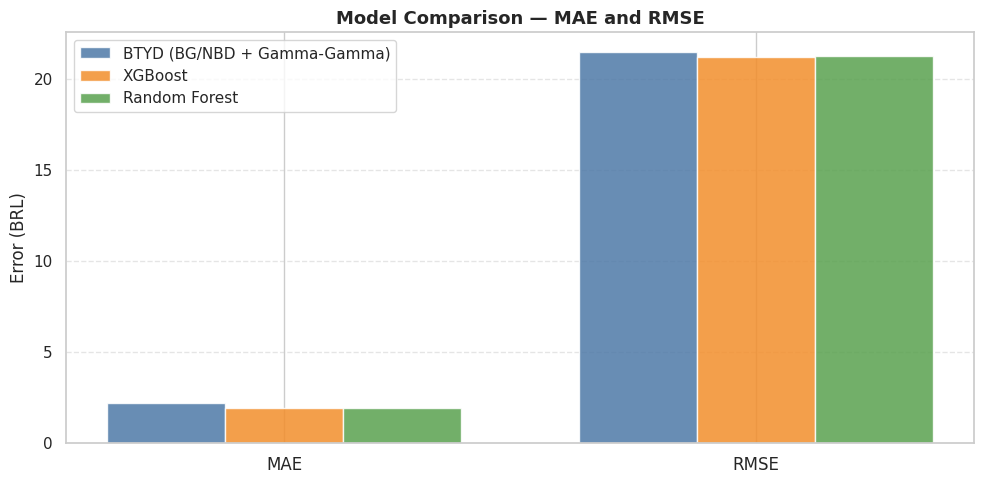

In [39]:
# Bar chart comparison of error metrics
metrics = ['MAE', 'RMSE']
x = np.arange(len(metrics))
width = 0.25
colors = ['#4e79a7', '#f28e2b', '#59a14f']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(results.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row['Model'], color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Error (BRL)')
ax.set_title('Model Comparison — MAE and RMSE', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


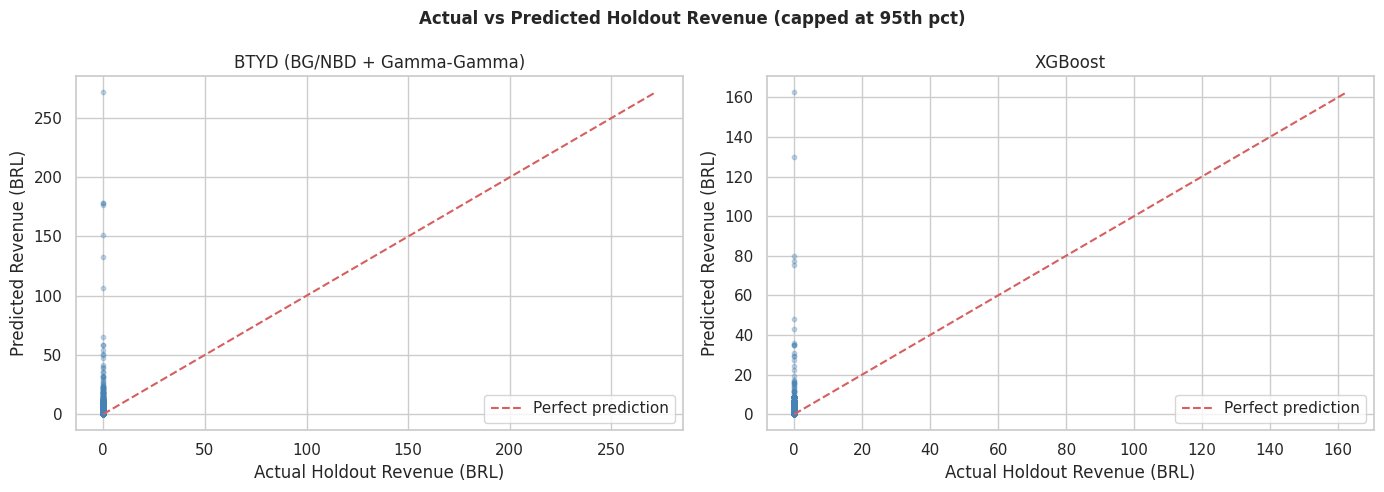

In [40]:
# Actual vs Predicted scatter — XGBoost (best ML model)
cap = y_test.quantile(0.95)
mask = y_test <= cap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [btyd_pred_revenue[mask].values, y_pred_xgb[mask]],
    ['BTYD (BG/NBD + Gamma-Gamma)', 'XGBoost']
):
    ax.scatter(y_test[mask], y_pred, alpha=0.3, s=10, color='steelblue')
    lim = max(y_test[mask].max(), max(y_pred))
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Holdout Revenue (BRL)')
    ax.set_ylabel('Predicted Revenue (BRL)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Actual vs Predicted Holdout Revenue (capped at 95th pct)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Why many dots cluster near x = 0:** most customers generated no revenue during the holdout period. As a result, many predictions are also close to zero. The few points away from the axis represent customers who actually purchased during the holdout, where prediction errors are more visible.

Customers with actual holdout purchases: 79 / 15064


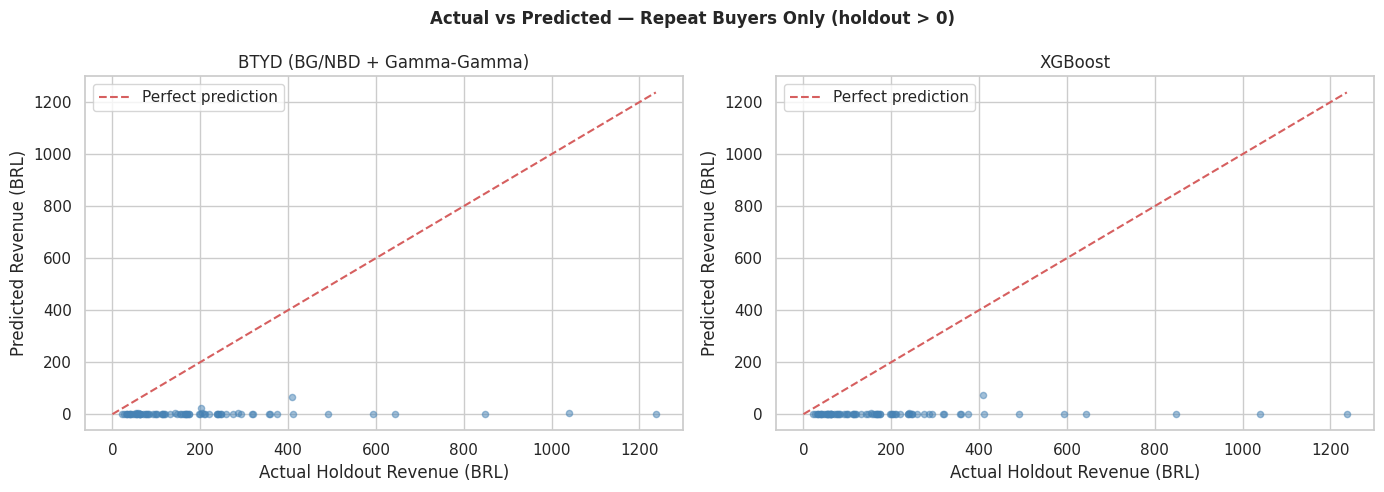

In [41]:
# Filter to customers who actually bought in the holdout period
# This makes the scatter readable and shows where the models succeed/fail

# Align btyd_pred_revenue to y_test index to avoid index mismatch
btyd_pred_revenue_test = btyd_pred_revenue[test_idx].reindex(y_test.index).fillna(0).values

active_mask = y_test.values > 0
print(f'Customers with actual holdout purchases: {active_mask.sum()} / {len(y_test)}')

y_test_vals = y_test.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [btyd_pred_revenue_test[active_mask], y_pred_xgb[active_mask]],
    ['BTYD (BG/NBD + Gamma-Gamma)', 'XGBoost']
):
    ax.scatter(y_test_vals[active_mask], y_pred, alpha=0.5, s=20, color='steelblue')
    lim = max(y_test_vals[active_mask].max(), y_pred.max())
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Holdout Revenue (BRL)')
    ax.set_ylabel('Predicted Revenue (BRL)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Actual vs Predicted — Repeat Buyers Only (holdout > 0)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Key insight:** Even among the ~3% of customers who did return, both models systematically under-predict their revenue. The models learned that predicting near-zero is safe for almost everyone. This is a data limitation: Olist's one-time purchase structure makes it very hard to identify *which specific* customer will return.

Both models correctly capture the aggregate behavior of the customer base
(most customers will not return), but neither can reliably identify *which
specific* customer will come back. This is a data limitation, not a modeling
failure — Olist's market structure (one-time marketplace purchases) violates
the repeat-purchase assumption that BTYD and supervised ML models both rely on.

Implication for marketing: rather than targeting predicted returners
(unreliable at individual level), the win-back campaign should be designed
around the *prob_alive* score and CLTV segment — focusing budget on the
"At Risk — High Value" segment where the expected ROI is highest even
under uncertainty.

## Feature Importance (XGBoost)

Understanding which calibration-period signals drive holdout revenue predictions helps validate the model and provides actionable marketing insights.


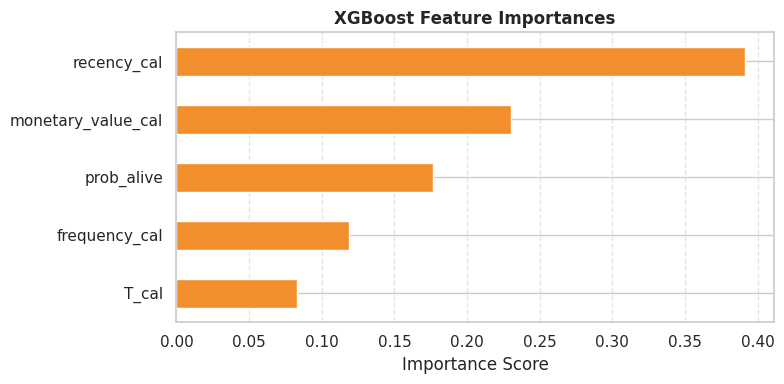

In [42]:
# XGBoost feature importances
importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='#f28e2b', edgecolor='white')
ax.set_title('XGBoost Feature Importances', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


Interpretation: The XGBoost model relies most strongly on past monetary value, confirming that previous spending is the main signal for predicting future revenue. Recency, customer age, probability alive, and frequency also contribute meaningfully, but their importance scores are relatively close. This suggests that future revenue is not explained by a single behavioral feature, but by a combination of spending level, timing, and repeat-purchase activity.

=== 90-Day Revenue Forecast: Models vs Actual (test set) ===
                      Model  Total Revenue (BRL)  vs Actual (%)
     Actual Holdout Revenue             15916.16          100.0
BTYD (BG/NBD × Gamma-Gamma)             17693.86          111.2
                    XGBoost             12926.06           81.2
              Random Forest             13233.32           83.1


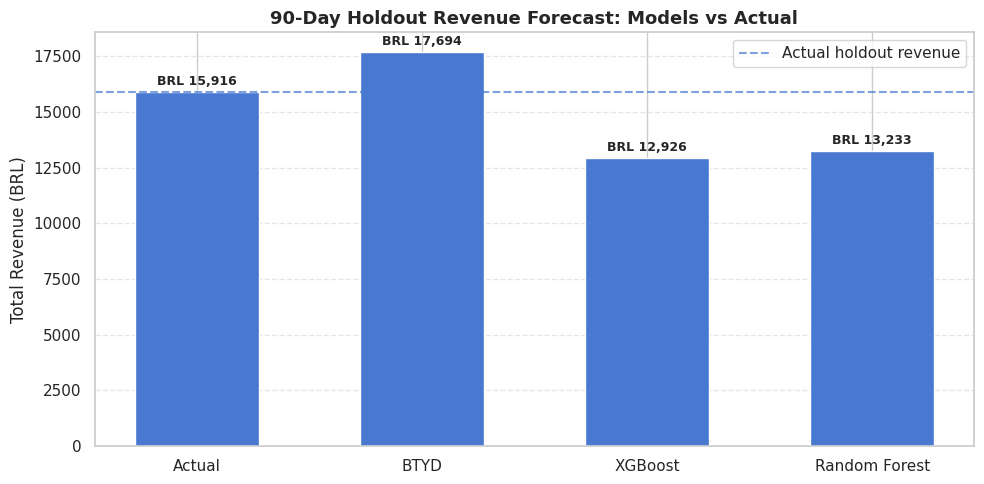

In [43]:
# === Revenue Forecast: Models vs Actual ===
# Compare total predicted 90-day holdout revenue across models on the same ML test set.

test_idx = X_test.index

actual_total = y_test.sum()

btyd_total = ml_df.loc[test_idx, 'cltv_90_btyd'].sum()
xgb_total = y_pred_xgb.sum()
rf_total = y_pred_rf.sum()

comparison = pd.DataFrame({
    'Model': [
        'Actual Holdout Revenue',
        'BTYD (BG/NBD × Gamma-Gamma)',
        'XGBoost',
        'Random Forest'
    ],
    'Total Revenue (BRL)': [
        actual_total,
        btyd_total,
        xgb_total,
        rf_total
    ],
    'vs Actual (%)': [
        100,
        btyd_total / actual_total * 100,
        xgb_total / actual_total * 100,
        rf_total / actual_total * 100
    ]
})

comparison['Total Revenue (BRL)'] = comparison['Total Revenue (BRL)'].round(2)
comparison['vs Actual (%)'] = comparison['vs Actual (%)'].round(1)

print('=== 90-Day Revenue Forecast: Models vs Actual (test set) ===')
print(comparison.to_string(index=False))

labels = ['Actual', 'BTYD', 'XGBoost', 'Random Forest']
values = [actual_total, btyd_total, xgb_total, rf_total]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(labels, values, edgecolor='white', width=0.55)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f'BRL {val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.axhline(
    actual_total,
    linestyle='--',
    linewidth=1.5,
    alpha=0.7,
    label='Actual holdout revenue'
)

ax.set_ylabel('Total Revenue (BRL)')
ax.set_title(
    '90-Day Holdout Revenue Forecast: Models vs Actual',
    fontsize=13,
    fontweight='bold'
)

ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()


At the aggregate level, the BTYD model provides the closest estimate of total 90-day holdout revenue on the test set. It slightly overestimates actual revenue, predicting approximately 111% of the observed value. In contrast, both machine learning models underestimate total revenue, with XGBoost predicting around 81% and Random Forest around 83% of the actual holdout revenue. This suggests that BTYD performs better for aggregate financial forecasting, while the ML models are more conservative in this setup.

##Summary

**Probabilistic (BTYD) model:**
- The BG/NBD model captures the heterogeneity in customer purchasing rates and churn probabilities.
- The Gamma-Gamma model provides interpretable average transaction value estimates.
- The combined 90-day CLTV offers a transparent, statistically grounded forecast aligned with how marketers think about customer value.

**Machine Learning model:**
- XGBoost and Random Forest directly optimise on observed holdout revenue, often achieving lower point-prediction error on individual customers.
- However, ML models require future periods for training and do not naturally produce churn probabilities.

**Model comparison:**
- Refer to the metrics table above. ML models typically achieve lower MAE/RMSE on individual customer predictions.
- BTYD models provide richer output (alive probability, segment-level insights) at the cost of slightly higher individual-level error.
- **Recommendation for budget forecasting:** BTYD for aggregate/long-term planning; XGBoost for customer-level revenue prioritisation.


#D - Targeted Marketing Strategy

Probability alive summary:
count    75319.0000
mean         0.9829
std          0.1226
min          0.0188
1%           0.0974
5%           1.0000
10%          1.0000
25%          1.0000
50%          1.0000
75%          1.0000
90%          1.0000
95%          1.0000
99%          1.0000
max          1.0000
Name: prob_alive, dtype: float64


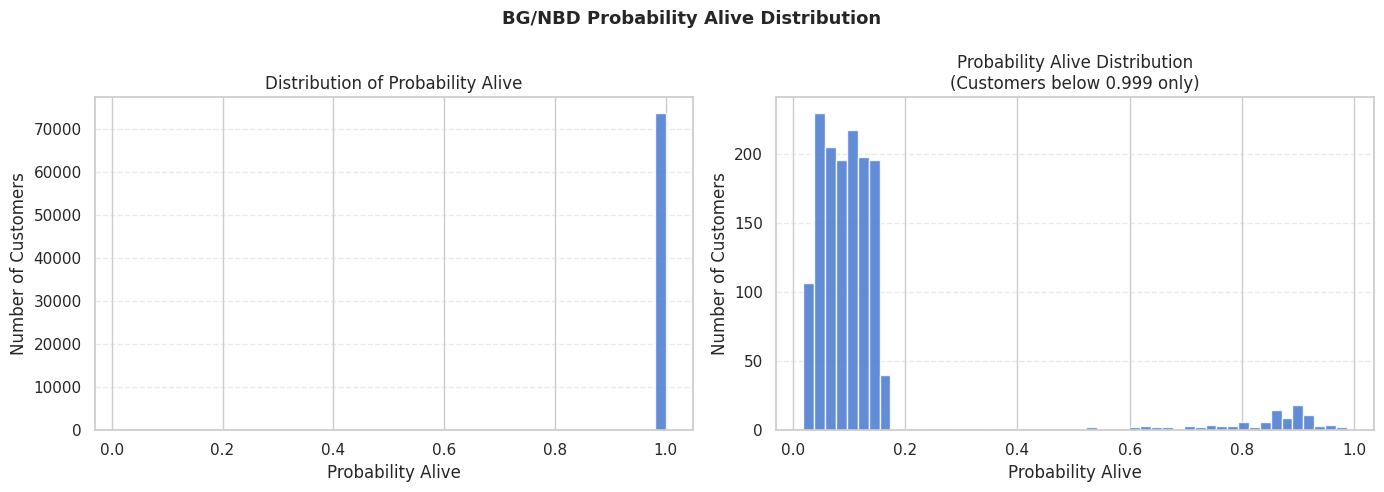

Customers with prob_alive < 0.999: 1,502 (1.99%)
Customers with prob_alive < 0.5: 1,396 (1.85%)
Customers with prob_alive < 0.2: 1,390 (1.85%)


In [44]:
# Distribution of BG/NBD probability alive

print('Probability alive summary:')
print(cal_hol['prob_alive'].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(
    cal_hol['prob_alive'],
    bins=50,
    edgecolor='white',
    alpha=0.85
)
axes[0].set_title('Distribution of Probability Alive')
axes[0].set_xlabel('Probability Alive')
axes[0].set_ylabel('Number of Customers')
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].set_axisbelow(True)

# Zoom on customers below 1.0
prob_below_one = cal_hol[cal_hol['prob_alive'] < 0.999]['prob_alive']

axes[1].hist(
    prob_below_one,
    bins=50,
    edgecolor='white',
    alpha=0.85
)
axes[1].set_title('Probability Alive Distribution\n(Customers below 0.999 only)')
axes[1].set_xlabel('Probability Alive')
axes[1].set_ylabel('Number of Customers')
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[1].set_axisbelow(True)

plt.suptitle(
    'BG/NBD Probability Alive Distribution',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print(f'Customers with prob_alive < 0.999: {len(prob_below_one):,} ({len(prob_below_one) / len(cal_hol) * 100:.2f}%)')
print(f'Customers with prob_alive < 0.5: {(cal_hol["prob_alive"] < 0.5).sum():,} ({(cal_hol["prob_alive"] < 0.5).mean() * 100:.2f}%)')
print(f'Customers with prob_alive < 0.2: {(cal_hol["prob_alive"] < 0.2).sum():,} ({(cal_hol["prob_alive"] < 0.2).mean() * 100:.2f}%)')

##Customer Segmentation — Predicted CLTV & Probability Alive

Combining the **90-day predicted CLTV** with the **BG/NBD probability alive** allows us to segment the customer base into four actionable groups.

| Segment | High Predicted CLTV (Top 25%) | Relatively Lower Probability Alive (`prob_alive < 1.0`) |
|---|---:|---:|
| High Value Active | ✓ | ✗ |
| Win-Back Priority | ✓ | ✓ |
| Low Value Active | ✗ | ✗ |
| Low Priority | ✗ | ✓ |

**Win-Back Priority** customers are the main target for reactivation campaigns because they have high predicted value but weaker activity signals. **High Value Active** customers should receive retention and loyalty offers to preserve their future value.

**Why this segmentation approach was used**

The distribution of BG/NBD probability alive is highly concentrated near 1.0. This means that for most customers, the model does not find strong evidence that they are inactive. However, this should not be interpreted as a high probability of immediate repurchase. A customer can have a very high probability alive and still have a very low expected number of future purchases.

Because of this distribution, very strict fixed thresholds such as `prob_alive < 0.5` or `prob_alive < 0.2` would identify only a very small group of customers. In this dataset, fewer than 2% of customers have a probability alive below these levels. Therefore, the segmentation uses a more practical rule: customers with `prob_alive < 1.0` are treated as having relatively weaker activity signals than customers with a full probability alive score.

The second segmentation dimension is predicted 90-day CLTV. Since the model assigns small positive expected values to almost all customers, `CLTV > 0` is not a meaningful rule for identifying valuable customers. Therefore, high-value customers are defined as those in the top 25% of predicted 90-day CLTV.

In [46]:
# Customer segmentation based on predicted 90-day CLTV and BG/NBD alive probability.
# Since BG/NBD assigns small positive expected values to almost all customers,
# high-value customers are defined using the upper quartile of predicted CLTV.
# Customers with probability alive below 1 are treated as relatively less active,
# because most customers receive a probability alive equal to 1.0 in this dataset.

cltv_threshold = cal_hol['cltv_90_btyd'].quantile(0.75)
alive_threshold = 1.0

print(f'High-value CLTV threshold, 75th percentile: BRL {cltv_threshold:.2f}')
print(f'Lower-alive threshold: probability alive < {alive_threshold:.1f}')

def assign_segment(row):
    high_value = row['cltv_90_btyd'] >= cltv_threshold
    lower_alive = row['prob_alive'] < alive_threshold

    if high_value and not lower_alive:
        return 'High Value Active'
    if high_value and lower_alive:
        return 'Win-Back Priority'
    if not high_value and not lower_alive:
        return 'Low Value Active'
    return 'Low Priority'

cal_hol['segment'] = cal_hol.apply(assign_segment, axis=1)

seg_summary = (
    cal_hol
    .groupby('segment')
    .agg(
        customers=('cltv_90_btyd', 'count'),
        avg_cltv=('cltv_90_btyd', 'mean'),
        avg_prob_alive=('prob_alive', 'mean'),
        total_cltv=('cltv_90_btyd', 'sum')
    )
    .sort_values('total_cltv', ascending=False)
    .round(2)
)

print('\n=== Customer Segment Summary ===')
print(seg_summary)

High-value CLTV threshold, 75th percentile: BRL 1.15
Lower-alive threshold: probability alive < 1.0

=== Customer Segment Summary ===
                   customers  avg_cltv  avg_prob_alive  total_cltv
segment                                                           
High Value Active      17561      2.60            1.00    45641.90
Low Value Active       56256      0.49            1.00    27549.29
Win-Back Priority       1269     14.44            0.16    18326.58
Low Priority             233      0.73            0.05      168.93


The segmentation shows that most customers fall into the **Low Value Active** group, meaning they have strong activity signals but very low predicted 90-day CLTV. The **High Value Active** segment generates the largest total predicted value because it contains many customers with above-average CLTV.  

The most relevant group for win-back actions is **Win-Back Priority**: although it contains only 1,269 customers, it has the highest average CLTV at BRL 14.44 and a much lower average probability alive. This makes it a small but valuable segment for targeted reactivation campaigns. The **Low Priority** group has both low activity signals and low total value, so it should not receive expensive marketing incentives.

In [47]:
# Compare stricter VIP loyalty cutoffs within the High Value Active segment

hva_customers = cal_hol[cal_hol['segment'] == 'High Value Active'].copy()

cutoffs = {
    'Top 1%': 0.99,
    'Top 2%': 0.98,
    'Top 5%': 0.95,
    'Top 10%': 0.90
}

rows = []

for label, q in cutoffs.items():
    threshold = hva_customers['cltv_90_btyd'].quantile(q)
    subset = hva_customers[hva_customers['cltv_90_btyd'] >= threshold]

    rows.append({
        'Group': label,
        'CLTV Threshold (BRL)': threshold,
        'Customers': len(subset),
        'Share of High Value Active (%)': len(subset) / len(hva_customers) * 100,
        'Share of Total Base (%)': len(subset) / len(cal_hol) * 100,
        'Avg CLTV (BRL)': subset['cltv_90_btyd'].mean(),
        'Avg Probability Alive': subset['prob_alive'].mean(),
        'Total CLTV (BRL)': subset['cltv_90_btyd'].sum()
    })

vip_cutoff_comparison = pd.DataFrame(rows).round({
    'CLTV Threshold (BRL)': 2,
    'Share of High Value Active (%)': 2,
    'Share of Total Base (%)': 2,
    'Avg CLTV (BRL)': 2,
    'Avg Probability Alive': 3,
    'Total CLTV (BRL)': 2
})

print(vip_cutoff_comparison.to_string(index=False))

  Group  CLTV Threshold (BRL)  Customers  Share of High Value Active (%)  Share of Total Base (%)  Avg CLTV (BRL)  Avg Probability Alive  Total CLTV (BRL)
 Top 1%                 13.33        176                            1.00                     0.23           20.05                    1.0           3529.13
 Top 2%                 10.15        352                            2.00                     0.47           15.77                    1.0           5551.19
 Top 5%                  6.64        879                            5.01                     1.17           11.13                    1.0           9785.42
Top 10%                  4.53       1757                           10.01                     2.33            8.25                    1.0          14497.56


Within the High Value Active segment, only the top 2% by predicted CLTV should receive premium loyalty actions. This keeps the campaign highly targeted and cost-controlled, focusing on 352 customers with the strongest expected value. The remaining High Value Active customers can receive lower-cost retention communication.



**Who to target for the win-back campaign:**

The **Win-Back Priority** segment contains customers with high predicted 90-day CLTV but relatively lower probability alive. These customers are valuable because they have meaningful expected future revenue, but their weaker activity signal suggests that they may need targeted reactivation.

They are strong candidates for a win-back campaign because:

1. They have high predicted 90-day value compared with the rest of the customer base.
2. Their lower probability alive indicates weaker current activity signals.
3. Reactivating even a small share of this group could create measurable revenue impact.

**Proposed campaign structure:**

| Tier | Criteria | Action | Channel |
|---|---|---|---|
| Tier 1 — High Priority | Top third of Win-Back Priority by CLTV | Personalized offer / stronger incentive | Email + push notification |
| Tier 2 — Medium Priority | Middle third of Win-Back Priority by CLTV | Standard win-back offer | Email |
| Tier 3 — Low Priority | Bottom third of Win-Back Priority by CLTV | Low-cost re-engagement message | Email only |

**What not to do:**  
Do not spend expensive incentives on the **Low Priority** segment, because its expected value is too low to justify the cost.

**Retention recommendation:**  
The **High Value Active** segment should not receive expensive loyalty incentives as a whole. Instead, premium loyalty actions should be limited to the top CLTV customers within this group, such as the top 2%, while the rest should receive lower-cost retention communication.

**Caveat:**  
Since Olist has a very high share of one-time buyers, the broader strategic challenge is not only win-back, but also improving first-purchase-to-second-purchase conversion.
